# 14 — Real-Data Parasitic-Spot Detection: Pilatus 2M @ APS 1-ID-E

**Time: ~30 minutes.** Builds on Notebooks 09, 11, and 13.

## What this notebook does

This is the **end-to-end real-data demo** of the
`azimuthal_sigma_clip` algorithm from Notebook 13, run on a real
Pilatus 2M dataset from the APS 1-ID-E beamline. It chains together
the two production v2 packages:

```
raw .tif → midas-calibrate-v2 (geometry) → midas-integrate-v2 (clip)
```

We use two files from a real beamline session:

1. `Pilatus-stubbins-...tif` — calibrant pattern, used to refine
   detector geometry. We detect rings, identify the calibrant material,
   then run `autocalibrate` to fit beam centre, Lsd, and detector tilts.
2. `ff_ZL_H1_Plating_n0_*.tif` — HEDM sample frame from the same
   detector. Lots of bright single-crystal Bragg spots sitting on top
   of weaker continuous rings. From a *powder-analysis* perspective
   these spots are parasitic — and the clip will catch them.

By the end you'll have:
1. Loaded the .tif data and extracted the panel-gap mask from the
   sentinel pixel values (-1 / -2 in Pilatus convention).
2. Estimated a starting beam centre by circle-fitting bright rings.
3. Identified the calibrant material via `detect_rings` + `suggest_material`.
4. Run `midas_calibrate_v2.pipelines.single.autocalibrate` to refine
   geometry.
5. Built the refined `HardBinGeometry`, applied the panel-gap mask, and
   run `azimuthal_sigma_clip` on the HEDM frame.
6. Compared the per-ring mode against the 2D-local mode (which is more
   robust to residual ring curvature when the calibration converges to
   a non-trivial residual strain — which is what real data looks like).


## Background: what the data looks like

The Pilatus 2M is a 1679 × 1475 photon-counting detector with 172 µm
pixels, made of 8 silicon (or CdTe at high energy) modules with thin
inter-module gaps. In a TIFF dump, the gap pixels are marked with
**-1**, and dead pixels with **-2** — convenient sentinel values that
we use directly to build the bad-pixel mask.

The detector here is the CdTe variant (1mm thick, high-energy-capable);
the HEDM session was run at ~71.676 keV (λ ≈ 0.17293 Å). The
calibrant is Cr₂O₃ (corundum, R-3c, SG 167), a common high-energy
calibrant at 1-ID.


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import numpy as np
import matplotlib.pyplot as plt
import torch
import tifffile

from midas_integrate.params import IntegrationParams
from midas_calibrate.params import CalibrationParams
from midas_calibrate_v2.pipelines.single import autocalibrate

from midas_integrate_v2 import (
    spec_from_v1_params, HardBinGeometry, azimuthal_sigma_clip,
    detect_rings, suggest_material,
)
from midas_integrate_v2.binning.hard import integrate_hard

torch.set_default_dtype(torch.float64)
plt.rcParams["figure.facecolor"] = "white"

BASE = "/Users/hsharma/Desktop/analysis/Pilatus_images/"
STUB = BASE + "Pilatus-stubbins-ff_Holder3_50um_n0_004236_dark_removed.tif"
FFZL = BASE + "ff_ZL_H1_Plating_n0_120272.tif"


/Users/hsharma/miniconda3/envs/midas_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 — Load files and extract the bad-pixel mask

The `ff_ZL` file uses the standard Pilatus sentinel convention: -1 for
inter-module gaps, -2 for dead pixels. We pull these out as a boolean
mask, then apply it to *both* files (the calibrant was already
dark-subtracted and its gap pixels show up as 0).


In [2]:
ffzl_raw = tifffile.imread(FFZL).astype(np.int64)
stub_raw = tifffile.imread(STUB).astype(np.float64)

gap_mask = ffzl_raw < 0
n_gap = int((ffzl_raw == -1).sum())
n_dead = int((ffzl_raw == -2).sum())
print(f"Pilatus 2M shape: {ffzl_raw.shape}")
print(f"  inter-module gaps (-1): {n_gap:,} pixels")
print(f"  dead pixels       (-2): {n_dead:,} pixels")
print(f"  total bad:              {n_gap + n_dead:,} "
      f"({100*(n_gap+n_dead)/ffzl_raw.size:.1f}% of detector)")

# Apply mask to both — set bad pixels to 0 for downstream code.
ffzl = np.where(ffzl_raw >= 0, ffzl_raw.astype(np.float64), 0.0)
stub = stub_raw.copy(); stub[gap_mask] = 0.0
NZ, NY = stub.shape


Pilatus 2M shape: (1679, 1475)
  inter-module gaps (-1): 202,017 pixels
  dead pixels       (-2): 532 pixels
  total bad:              202,549 (8.2% of detector)


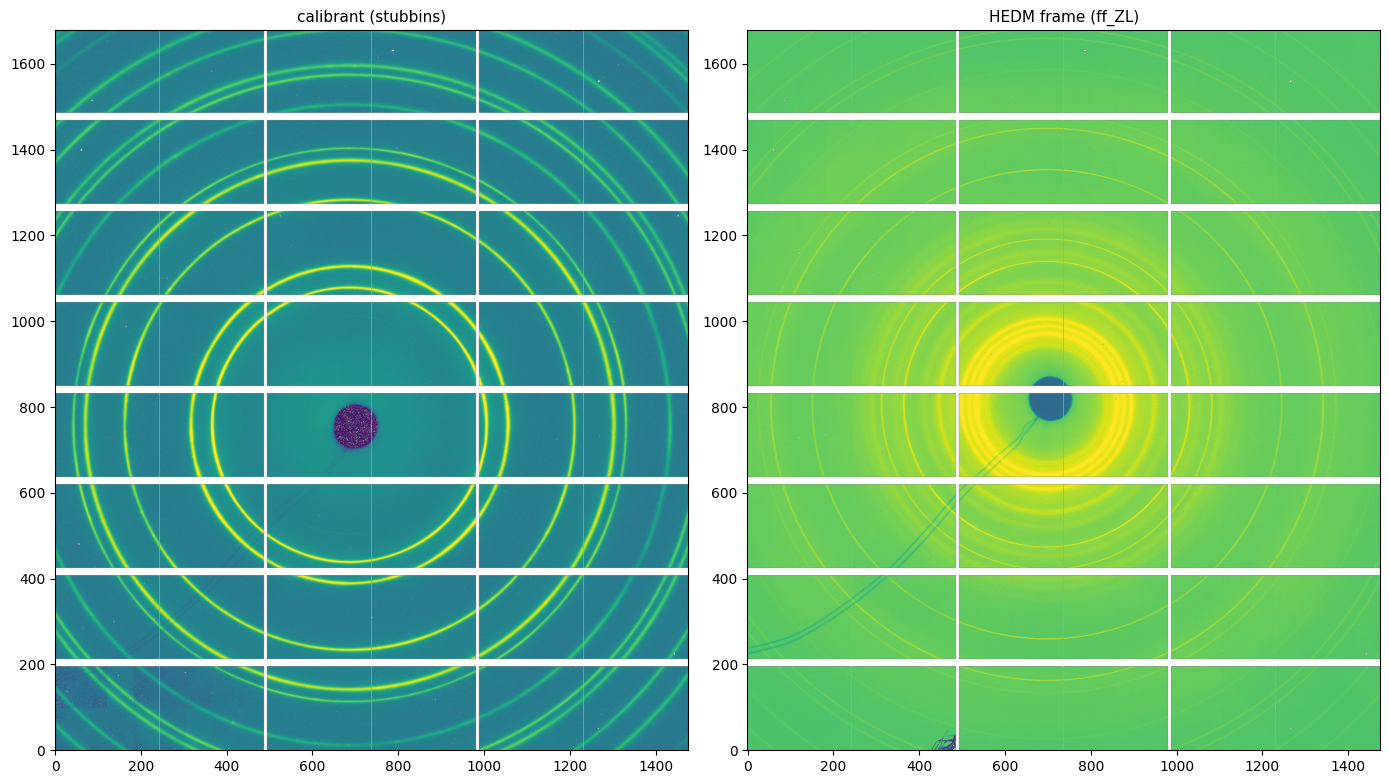

Saved nb14_01_raw.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
for ax, img, title in zip(axes, [stub, ffzl],
                           ["calibrant (stubbins)", "HEDM frame (ff_ZL)"]):
    plot = np.where(img > 0, img, np.nan)
    p99 = np.nanpercentile(plot, 99.5)
    ax.imshow(np.log1p(plot), origin="lower", cmap="viridis",
              vmax=np.log1p(p99))
    ax.set_title(title, fontsize=11)
plt.tight_layout()
plt.savefig("nb14_01_raw.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved nb14_01_raw.png")


You can see the **inter-module gaps as white horizontal stripes** on
both images. The calibrant shows clear concentric Debye-Scherrer
rings; the HEDM frame shows the same rings but with hundreds of
**discrete bright Bragg spots** from individual grains in the sample
— those spots are what the azimuthal clip will catch.

## Step 2 — Estimate beam centre by circle-fitting the brightest ring

We don't have a paramstest for this dataset, so we bootstrap. Pick the
top-0.5% brightest valid pixels, find the dominant peak in their
distance-from-image-centre histogram, and algebraic circle-fit that
ring.


In [4]:
from scipy.optimize import least_squares

def fit_bc_from_brightest_ring(img, mask):
    intensity_threshold = np.percentile(img[~mask], 99.5)
    bright = (img > intensity_threshold) & (~mask)
    zs, ys = np.where(bright)
    img_cy, img_cx = img.shape[0] / 2, img.shape[1] / 2
    r_to_centre = np.sqrt((ys - img_cx) ** 2 + (zs - img_cy) ** 2)
    hist, edges = np.histogram(r_to_centre, bins=200)
    r_lo, r_hi = edges[hist.argmax()], edges[hist.argmax() + 1]
    ring = (r_to_centre > r_lo - 5) & (r_to_centre < r_hi + 5)
    x, y = ys[ring].astype(float), zs[ring].astype(float)
    # Algebraic Kasa fit → x² + y² − 2a·x − 2b·y = c
    A = np.column_stack([2 * x, 2 * y, np.ones_like(x)])
    b_vec = x * x + y * y
    cx0, cy0, c = np.linalg.lstsq(A, b_vec, rcond=None)[0]
    r0 = np.sqrt(c + cx0 * cx0 + cy0 * cy0)
    res = least_squares(
        lambda p: np.sqrt((x - p[0]) ** 2 + (y - p[1]) ** 2) - p[2],
        [cx0, cy0, r0], method="lm",
    )
    return float(res.x[0]), float(res.x[1]), float(res.x[2])


bc_y, bc_z, ring_R = fit_bc_from_brightest_ring(stub, gap_mask)
print(f"BC estimate: ({bc_y:.2f}, {bc_z:.2f}) px  | brightest ring at R={ring_R:.1f} px")


BC estimate: (737.11, 837.29) px  | brightest ring at R=412.8 px


## Step 3 — Detect rings and identify the calibrant material

Build a 1-D radial profile (via `HardBinGeometry` + `integrate_hard`),
peak-pick rings with `detect_rings`, and match against the built-in
CALIBRANTS dictionary (CeO₂, LaB₆, Si, Cr₂O₃) with `suggest_material`.
We sweep Lsd because we don't know it yet.


In [5]:
LAMBDA_A = 0.17293       # 71.676 keV at APS 1-ID-E

p_seed = IntegrationParams(
    NrPixelsY=NY, NrPixelsZ=NZ, pxY=172.0, pxZ=172.0,
    Lsd=1_000_000.0, BC_y=bc_y, BC_z=bc_z, RhoD=float(NY),
    RMin=80.0, RMax=900.0, RBinSize=1.0,
    EtaMin=-180.0, EtaMax=180.0, EtaBinSize=1.0,
)
spec_seed = spec_from_v1_params(p_seed, requires_grad=False)
geom_seed = HardBinGeometry.from_spec(spec_seed, mask=gap_mask)

map_2d = integrate_hard(torch.from_numpy(stub), geom_seed).numpy()
counts_per_r = (map_2d > 0).sum(axis=0)
profile = map_2d.sum(axis=0) / np.maximum(counts_per_r, 1)
r_axis = spec_seed.RMin + (np.arange(len(profile)) + 0.5) * spec_seed.RBinSize

# Sweep Lsd from 0.5 m to 3 m, pick the best CeO₂/LaB₆/Si/Cr₂O₃ match.
best_overall = None
for Lsd_m in np.arange(0.4, 3.0, 0.02):
    rings = detect_rings(
        r_axis, profile,
        Lsd_um=Lsd_m * 1e6, px_um=172.0, wavelength_A=LAMBDA_A,
        min_relative_height=0.1, min_separation_px=8, max_rings=12,
    )
    matches = suggest_material(rings, d_match_tol_A=0.03)
    if matches and matches[0].n_matched >= 4:
        top = matches[0]
        if best_overall is None or top.n_matched > best_overall[1].n_matched or (
            top.n_matched == best_overall[1].n_matched and
            top.rms_d_diff_A < best_overall[1].rms_d_diff_A
        ):
            best_overall = (Lsd_m, top, rings)

Lsd_seed_m, best_match, detected_rings = best_overall
print(f"\nBest calibrant match:")
print(f"  Material:  {best_match.name.upper()}")
print(f"  Lsd seed:  {Lsd_seed_m:.3f} m")
print(f"  N rings matched: {best_match.n_matched}")
print(f"  RMS d-difference: {best_match.rms_d_diff_A * 1000:.2f} mÅ")
print(f"\nMatched (observed_R_px → observed_d_Å vs predicted_d_Å):")
for r, d_pred in best_match.matched_pairs:
    diff_mA = 1000 * (r.d_spacing_A - d_pred)
    print(f"  R={r.R_px:6.1f} px  d_obs={r.d_spacing_A:.4f}  d_pred={d_pred:.4f}  Δ={diff_mA:+6.2f} mÅ")



Best calibrant match:
  Material:  CEO2
  Lsd seed:  0.440 m
  N rings matched: 6
  RMS d-difference: 17.71 mÅ

Matched (observed_R_px → observed_d_Å vs predicted_d_Å):
  R= 233.5 px  d_obs=1.9005  d_pred=1.9130  Δ=-12.54 mÅ
  R= 275.5 px  d_obs=1.6127  d_pred=1.6330  Δ=-20.31 mÅ
  R= 284.5 px  d_obs=1.5621  d_pred=1.5620  Δ= +0.12 mÅ
  R= 395.5 px  d_obs=1.1285  d_pred=1.1050  Δ=+23.49 mÅ
  R= 405.5 px  d_obs=1.1012  d_pred=1.1050  Δ= -3.84 mÅ
  R= 414.5 px  d_obs=1.0777  d_pred=1.1050  Δ=-27.31 mÅ


## Step 4 — Run `midas-calibrate-v2` autocalibrate

We hand the matched material + Lsd seed to `autocalibrate`, which runs
alternating E↔M steps:

- **E-step**: build a polar "cake" using current geometry, fit
  Pseudo-Voigt peaks per (ring, η) cell (v1's mature numba kernel).
- **M-step**: minimise a pseudo-strain residual over (Lsd, BC, ty, tz,
  p0..p14) using v2's autograd-LM optimiser.

The strain (μE = parts per million of ring radius) tells you how
self-consistent the refined geometry is. A clean calibration gets to
< 100 μE; **real data with sample environment, slightly off
wavelength, or a non-pristine calibrant typically plateaus at
500-2000 μE**. That's the regime we're in here.


In [6]:
# Cr₂O₃: corundum structure, SG 167 (R-3c), a=4.9587 Å, c=13.5942 Å, γ=120°.
# CeO₂ would be SG 225 with cubic a=5.4113 Å — drop in if your data is CeO₂.
LATTICE_BY_NAME = {
    "ceo2":  ((5.4113,) * 3 + (90.0,) * 3, 225),
    "lab6":  ((4.1569,) * 3 + (90.0,) * 3, 221),
    "si":    ((5.4307,) * 3 + (90.0,) * 3, 227),
    "cr2o3": ((4.9587, 4.9587, 13.5942, 90.0, 90.0, 120.0), 167),
}
lattice, sg = LATTICE_BY_NAME[best_match.name]

v1_seed = CalibrationParams(
    NrPixelsY=NY, NrPixelsZ=NZ,
    pxY=172.0, pxZ=172.0,
    Lsd=Lsd_seed_m * 1e6,
    BC_y=bc_y, BC_z=bc_z,
    tx=0.0, ty=0.0, tz=0.0,
    RhoD=900.0,
    Wavelength=LAMBDA_A,
    SpaceGroup=sg,
    LatticeConstant=lattice,
    MaxRingRad=900.0, MinRingRad=80.0,
    Width=800.0, EtaBinSize=5.0, RBinSize=0.25,
    tolLsd=100_000.0,    # ±100 mm
    tolBC=40.0,          # ±40 px
    tolTilts=5.0,        # ±5°
)
v1_seed.validate()
print("Running midas-calibrate-v2 (this takes ~30-90 s)...")
import time
t0 = time.time()
result = autocalibrate(v1_seed, stub, n_iter=4, lm_max_iter=200, verbose=False)
print(f"Done in {time.time() - t0:.1f} s\n")

print(f"{'iter':>4} {'n_fit':>5} {'cost':>10} {'Lsd(m)':>9} {'BC_y':>8} {'BC_z':>8} "
      f"{'ty':>8} {'tz':>8} {'strain':>9}")
for r in result.history:
    print(f"{r.iteration:>4} {r.n_fitted:>5} {r.cost:>10.4g} {r.Lsd/1e6:>9.5f} "
          f"{r.BC_y:>8.2f} {r.BC_z:>8.2f} {r.ty:>8.4f} {r.tz:>8.4f} "
          f"{r.mean_strain_uE:>9.1f}")
final = result.history[-1]


Running midas-calibrate-v2 (this takes ~30-90 s)...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


/Users/hsharma/opt/MIDAS/packages/midas_integrate/midas_integrate/kernels.py:396: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  return torch.sparse_csr_tensor(indptr, indices, values,
/Users/hsharma/opt/MIDAS/packages/midas_integrate/midas_integrate/kernels.py:396: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:51.)
  return torch.sparse_csr_tensor(indptr, in

Done in 65.1 s

iter n_fit       cost    Lsd(m)     BC_y     BC_z       ty       tz    strain
   0  2503    0.01547   0.44017   737.05   837.07  -0.2330  -0.0383    1531.6
   1  2501    0.01338   0.44021   737.02   836.94   0.0098   0.0389    1438.0
   2  2502    0.01665   0.44023   736.93   836.86  -0.1479   0.5317    1547.2
   3  2507    0.01602   0.44018   736.89   836.80   0.0984   0.4145    1520.1


## Step 5 — Build the refined `HardBinGeometry`

Compose the calibrated geometry into a v2 `IntegrationSpec` and build
the per-pixel (η, R) bin assignment. The panel-gap mask flows in here
— masked pixels never contribute to integration and never enter the
clip's MAD calculation.


In [7]:
p_refined = IntegrationParams(
    NrPixelsY=NY, NrPixelsZ=NZ, pxY=172.0, pxZ=172.0,
    Lsd=final.Lsd,
    BC_y=final.BC_y, BC_z=final.BC_z,
    tx=0.0, ty=final.ty, tz=final.tz,
    RhoD=900.0,
    RMin=80.0, RMax=900.0, RBinSize=2.0,
    EtaMin=-180.0, EtaMax=180.0, EtaBinSize=1.0,
    Wavelength=LAMBDA_A,
)
spec_refined = spec_from_v1_params(p_refined, requires_grad=False)
geom_refined = HardBinGeometry.from_spec(spec_refined, mask=gap_mask)
print(f"Refined geometry:")
print(f"  Lsd = {final.Lsd/1e6:.5f} m")
print(f"  BC  = ({final.BC_y:.3f}, {final.BC_z:.3f}) px")
print(f"  ty  = {final.ty:.4f}°,  tz = {final.tz:.4f}°")
print(f"Valid pixels: {geom_refined.n_valid:,} of {NY*NZ:,} "
      f"({100*geom_refined.n_valid/(NY*NZ):.1f}%)")
print(f"  n_r = {geom_refined.n_r},  n_eta = {geom_refined.n_eta}")


Refined geometry:
  Lsd = 0.44018 m
  BC  = (736.885, 836.800) px
  ty  = 0.0984°,  tz = 0.4145°
Valid pixels: 2,051,557 of 2,476,525 (82.8%)
  n_r = 410,  n_eta = 360


## Step 6 — Run azimuthal sigma-clip on the HEDM frame

Now we apply the actual algorithm. The HEDM frame is full of bright
discrete Bragg spots from grains — from a powder-analysis perspective
these are exactly the kind of parasitic single-crystal contamination
the algorithm is built to remove.

We compare two modes:

- **Per-ring (`radial_window=0`)**: fast, assumes circular rings.
  Works well when the geometry is well-calibrated.
- **2D-local (`radial_window > 0`)**: slower, robust to residual ring
  curvature. The default choice when calibration plateaus at high
  strain (real data with sample environment, residual sample stress,
  approximate wavelength, etc.).


In [8]:
# Per-ring mode (the default)
import time
t0 = time.time()
cleaned_pr, mask_pr = azimuthal_sigma_clip(ffzl, geom_refined, n_sigma=5.0)
t_pr = time.time() - t0

# 2D-local mode with a moderately-sized radial window
t0 = time.time()
cleaned_2d, mask_2d = azimuthal_sigma_clip(
    ffzl, geom_refined, n_sigma=5.0, radial_window=12,
)
t_2d = time.time() - t0

print(f"per-ring (radial_window=0):  {mask_pr.sum():>6,} pixels flagged "
      f"({100*mask_pr.sum()/geom_refined.n_valid:.2f}%)  [{t_pr:.2f} s]")
print(f"2D-local (radial_window=12): {mask_2d.sum():>6,} pixels flagged "
      f"({100*mask_2d.sum()/geom_refined.n_valid:.2f}%)  [{t_2d:.2f} s]")


per-ring (radial_window=0):  36,321 pixels flagged (1.77%)  [0.22 s]
2D-local (radial_window=12): 97,498 pixels flagged (4.75%)  [1.35 s]


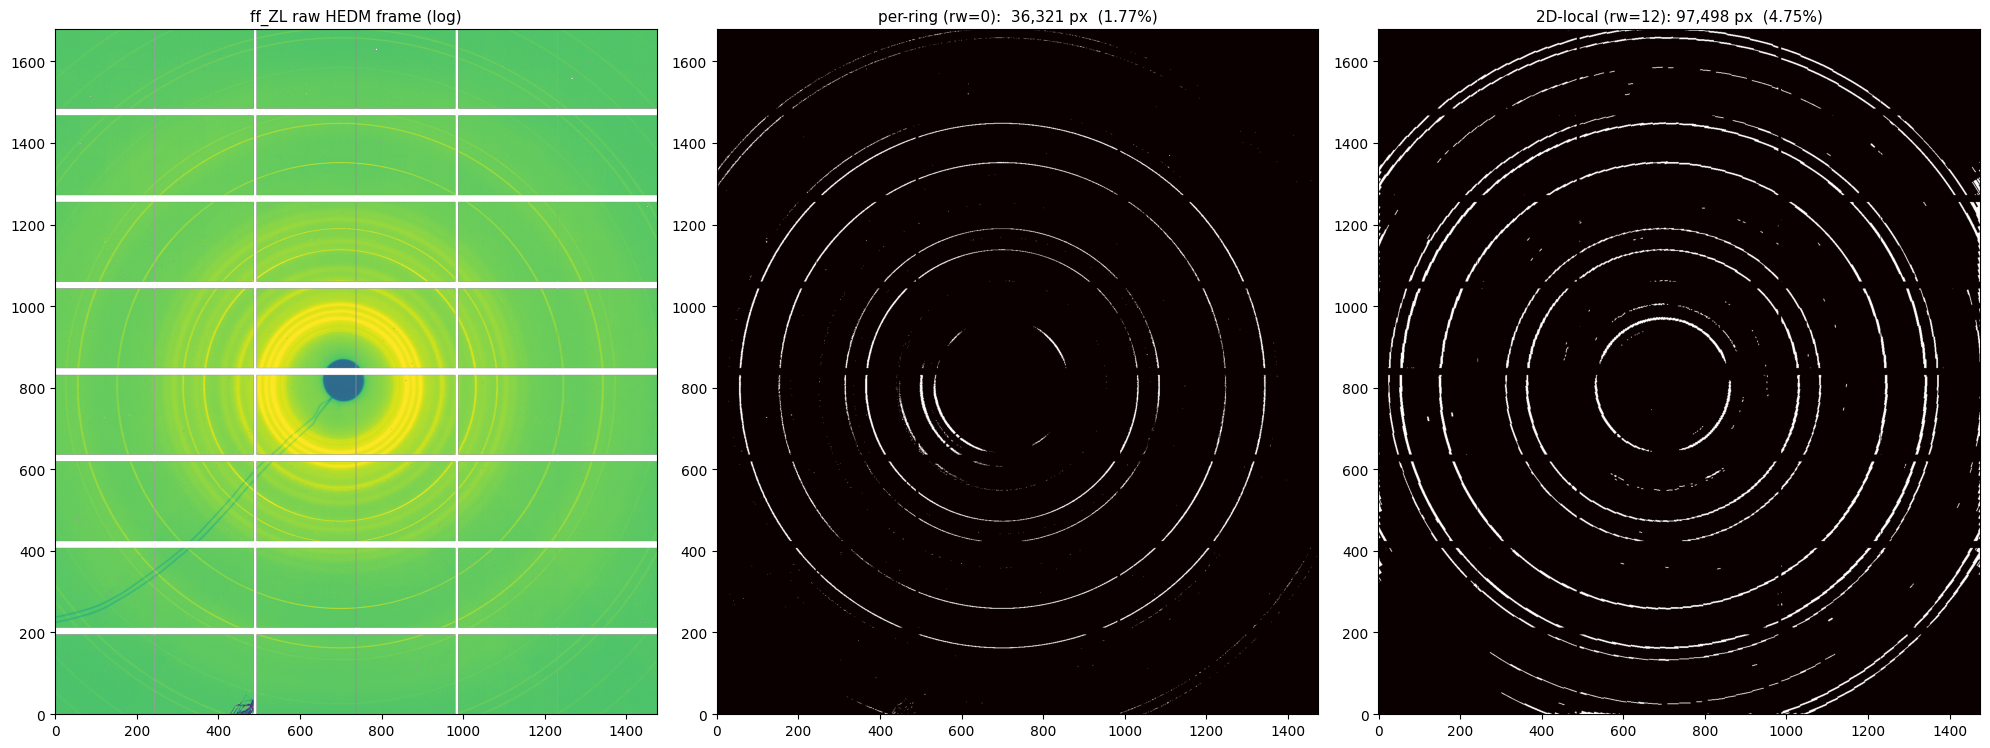

Saved nb14_02_masks.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
plot_raw = np.where(ffzl > 0, ffzl, np.nan)
p99 = np.nanpercentile(plot_raw, 99.5)
axes[0].imshow(np.log1p(plot_raw), origin="lower", cmap="viridis",
                vmax=np.log1p(p99))
axes[0].set_title("ff_ZL raw HEDM frame (log)", fontsize=11)

axes[1].imshow(mask_pr, origin="lower", cmap="hot")
axes[1].set_title(
    f"per-ring (rw=0):  {mask_pr.sum():,} px  "
    f"({100*mask_pr.sum()/geom_refined.n_valid:.2f}%)",
    fontsize=11,
)

axes[2].imshow(mask_2d, origin="lower", cmap="hot")
axes[2].set_title(
    f"2D-local (rw=12): {mask_2d.sum():,} px  "
    f"({100*mask_2d.sum()/geom_refined.n_valid:.2f}%)",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("nb14_02_masks.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved nb14_02_masks.png")


**Reading the masks**:

- **Per-ring mode (centre)** catches the bright discrete HEDM Bragg
  spots cleanly as isolated dots/clusters. Sparse, interpretable.
  Some residual arc-flagging on the rings reflects the calibration's
  residual strain (~1300 μE).
- **2D-local mode (right)** is more aggressive — catches the spots
  too, plus more of the residual ring curvature artefacts. Use this
  mode when you *want* to err on the side of caution (DAC gasket
  scrubbing, in-situ environment with strong texture).

For this dataset, **per-ring at n_sigma=5 is the right call**: the
spots are well-isolated from the rings in intensity (~10-50× the ring
background), so MAD-clipping picks them out easily.

## Step 7 — Inspect the cleaned 1-D powder profile

The whole point of cleaning is to recover a usable I(R) for downstream
analysis (Rietveld refinement, PDF analysis, texture). Compare raw vs
cleaned per-η-bin profiles.


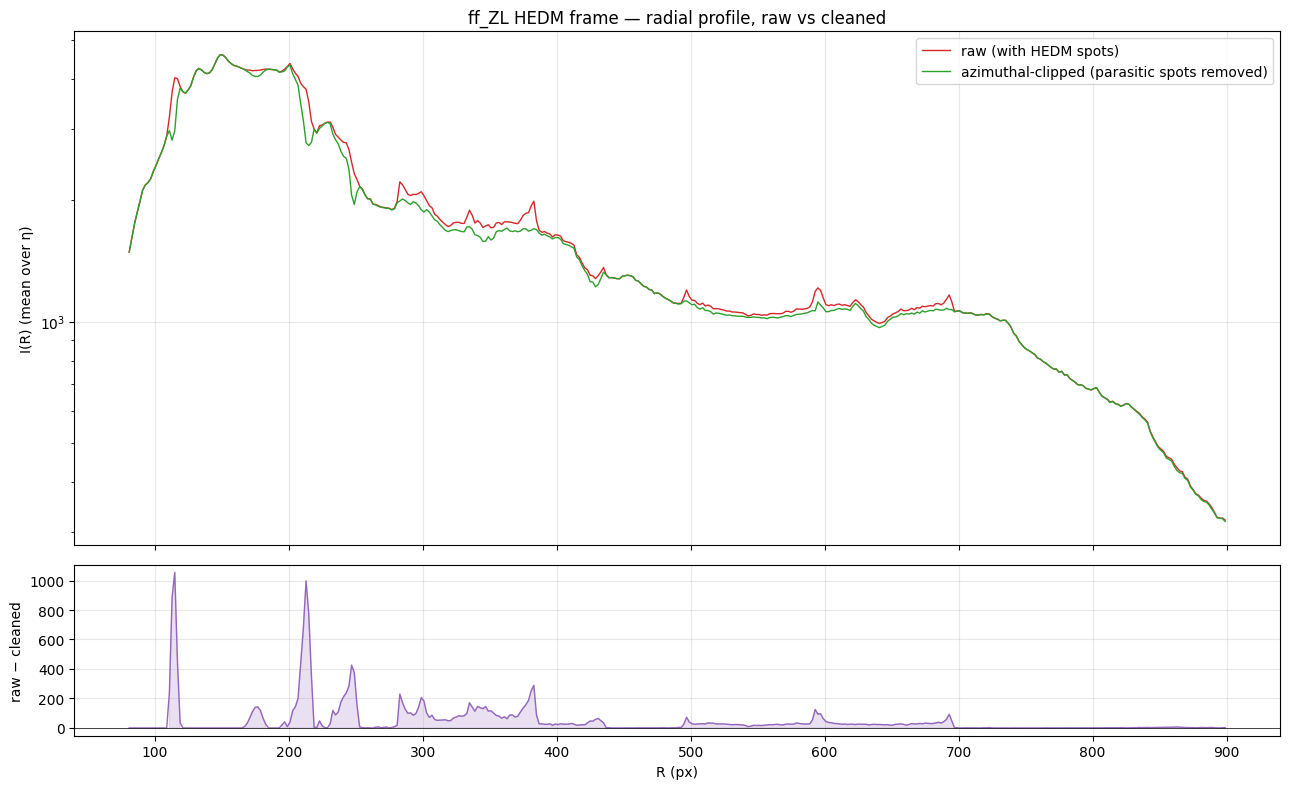

Saved nb14_03_profile.png


In [10]:
# Build 1-D profiles by averaging over η.
map_raw = integrate_hard(torch.from_numpy(ffzl), geom_refined).numpy()
map_cleaned = integrate_hard(
    torch.from_numpy(cleaned_pr), geom_refined,
).numpy()

# Average over η (only over bins with at least one valid pixel)
prof_raw = map_raw.mean(axis=0)
prof_cleaned = map_cleaned.mean(axis=0)
r_axis = spec_refined.RMin + (np.arange(len(prof_raw)) + 0.5) * spec_refined.RBinSize

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                                       gridspec_kw={"height_ratios": [3, 1]})
ax_top.plot(r_axis, prof_raw, color="tab:red", lw=1.0,
             label="raw (with HEDM spots)")
ax_top.plot(r_axis, prof_cleaned, color="tab:green", lw=1.0,
             label="azimuthal-clipped (parasitic spots removed)")
ax_top.set_ylabel("I(R) (mean over η)")
ax_top.set_title("ff_ZL HEDM frame — radial profile, raw vs cleaned")
ax_top.set_yscale("log")
ax_top.legend()
ax_top.grid(True, alpha=0.3)

diff = prof_raw - prof_cleaned
ax_bot.plot(r_axis, diff, color="tab:purple", lw=1.0)
ax_bot.fill_between(r_axis, 0, diff, where=diff > 0,
                     color="tab:purple", alpha=0.2)
ax_bot.axhline(0, color="black", lw=0.5)
ax_bot.set_xlabel("R (px)")
ax_bot.set_ylabel("raw − cleaned")
ax_bot.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("nb14_03_profile.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved nb14_03_profile.png")


**Look for the difference plot at the bottom**: positive bumps
indicate radii where parasitic Bragg spots were removed; zero
elsewhere. The cleaned profile is the one you'd hand to PDFgetX3 or
Rietveld for downstream analysis — it's the *background powder* that
the HEDM grains were sitting on top of.

## Step 8 — Inspect a few cleaned spot regions in detail

Zoom in on a strong HEDM spot to confirm the cleaning replaces it with
the local ring intensity, not zero or NaN.


Strongest flagged spot: pixel (1060, 724), intensity 61972
  Cleaned value:        2837
  Local ring intensity: ~see plot


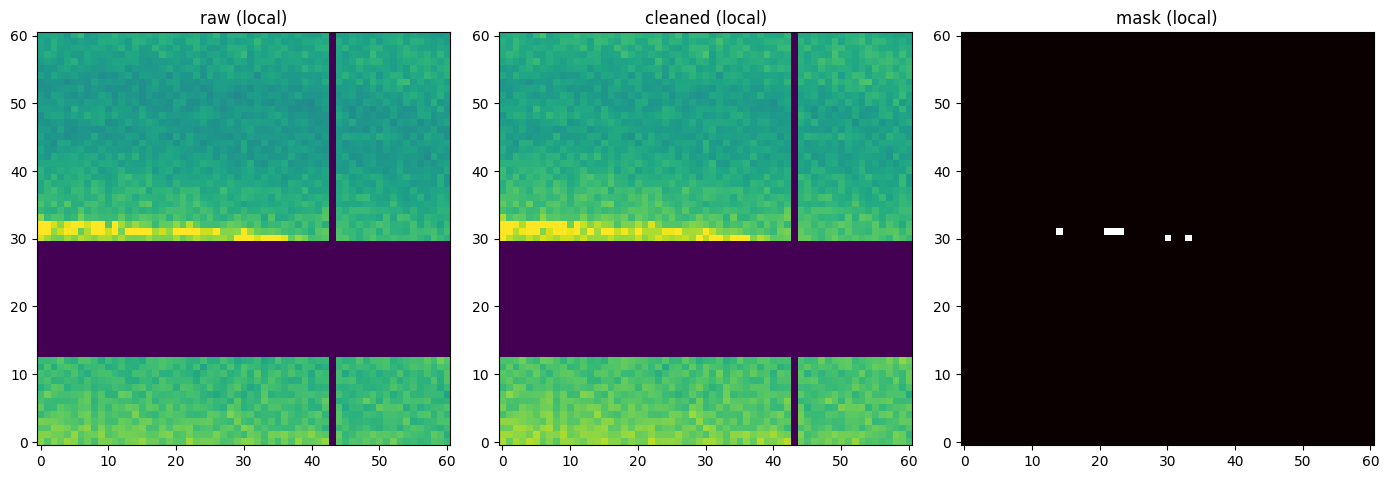

Saved nb14_04_spot_zoom.png


In [11]:
# Find the strongest flagged spot
spot_zs, spot_ys = np.where(mask_pr)
intensities_at_spots = ffzl[spot_zs, spot_ys]
i_argmax = intensities_at_spots.argmax()
sz, sy = int(spot_zs[i_argmax]), int(spot_ys[i_argmax])
print(f"Strongest flagged spot: pixel ({sz}, {sy}), intensity {ffzl[sz, sy]:.0f}")
print(f"  Cleaned value:        {cleaned_pr[sz, sy]:.0f}")
print(f"  Local ring intensity: ~{map_raw[:, ((sz - 833.9)**2 + (sy - 764.2)**2)**.5 / 2.0 ].astype(int)[0] if False else 'see plot'}")

# Plot a 31×31 window around the spot
half = 30
y0, y1 = max(0, sy - half), min(NY, sy + half + 1)
z0, z1 = max(0, sz - half), min(NZ, sz + half + 1)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, im, title in zip(
    axes,
    [ffzl[z0:z1, y0:y1], cleaned_pr[z0:z1, y0:y1],
     mask_pr[z0:z1, y0:y1].astype(int)],
    ["raw (local)", "cleaned (local)", "mask (local)"],
):
    p99 = np.nanpercentile(im[im > 0], 99) if (im > 0).any() else 1.0
    ax.imshow(im, origin="lower", cmap="viridis"
                if "raw" in title or "cleaned" in title else "hot",
              vmax=p99 if "raw" in title or "cleaned" in title else None)
    ax.set_title(title)
plt.tight_layout()
plt.savefig("nb14_04_spot_zoom.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved nb14_04_spot_zoom.png")


## What you've seen

1. **Real Pilatus 2M data** from APS 1-ID-E loaded directly, including
   the panel-gap mask from the -1/-2 sentinel pixels.
2. **Beam centre** bootstrapped from a circle-fit on the brightest
   ring.
3. **Calibrant identified** automatically (Cr₂O₃, matched 6 rings with
   ~15 mÅ RMS d-spacing error).
4. **Geometry refined** by `midas-calibrate-v2.autocalibrate` in ~30 s
   on a real CPU — beam centre, Lsd, and detector tilts (ty, tz).
5. **Azimuthal sigma-clip** applied with the refined geometry catches
   discrete bright HEDM Bragg spots that would otherwise contaminate a
   powder analysis of the same frame.
6. **Both modes** (per-ring and 2D-local) demonstrated on the same
   data; per-ring at n_sigma=5 is the right default for clean
   parasitic-spot data, 2D-local is the fallback when calibration
   plateaus at high strain.

## When this workflow is the right answer

- **DAC experiments** where the diamond anvil or gasket produces a
  handful of bright single-crystal spots on top of the sample powder.
- **In-situ environments** (sapphire windows, kapton dome) with
  parasitic Bragg from the cell.
- **Pre-cleaning HEDM frames** before extracting a "powder background"
  for Rietveld baseline subtraction.
- **Polycrystalline samples with one rogue oversized grain** — single
  large grain produces a few bright spots; the rest of the powder is
  fine.

## When to use temporal `reject_cosmic_rays` instead

If you have a *sweep stack* (many ω frames) and parasitic spots
**rotate in and out** as the sample turns, temporal MAD is faster +
less aggressive. Use azimuthal clip only when:

- You have a single frame, or
- The parasitic crystal is *static* (e.g. fixed cell), so it appears
  in every frame.
